# 06 - Weight Initialization Techniques and Gradient Investigations

This notebook investigates **weight initializations** and their impact on internal neural network dynamics:

---

## Key Topics:

1. **PyTorch Built-in Initializations (`torch.nn.init`)**:
   - Default (Kaiming uniform)
   - Xavier / Glorot (Normal & Uniform)
   - Kaiming / He (Normal & Uniform)
   - Orthogonal Initialization
   - Zero / Constant Initialization (Symmetry Breaking failure)
2. **Weight Distribution Investigations**: Plotting histograms of layer parameters before & after initialization.
3. **Gradient Dynamics & Hooking**: Tracking layer gradient magnitudes during backpropagation in a deep 10-layer FFN to observe **Vanishing vs Exploding Gradients**.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.init as init

np.random.seed(42)
torch.manual_seed(42)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')


## 1. PyTorch Initializations (`torch.nn.init`)

We define custom initialization functions using PyTorch's `torch.nn.init` module and apply them via `model.apply(init_function)`.


In [2]:
def init_weights_zero(m):
    if isinstance(m, nn.Linear):
        init.constant_(m.weight, 0.0)
        init.constant_(m.bias, 0.0)

def init_weights_xavier_normal(m):
    if isinstance(m, nn.Linear):
        init.xavier_normal_(m.weight)
        if m.bias is not None:
            init.constant_(m.bias, 0.0)

def init_weights_kaiming_normal(m):
    if isinstance(m, nn.Linear):
        init.kaiming_normal_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            init.constant_(m.bias, 0.0)

def init_weights_orthogonal(m):
    if isinstance(m, nn.Linear):
        init.orthogonal_(m.weight)
        if m.bias is not None:
            init.constant_(m.bias, 0.0)

def init_weights_exploding(m):
    if isinstance(m, nn.Linear):
        init.normal_(m.weight, mean=0.0, std=5.0) # Dangerously large std
        if m.bias is not None:
            init.constant_(m.bias, 0.0)


## 2. Visualizing Initial Weight Distributions Across Layers

Different initialization strategies create distinct probability distributions for weight values.


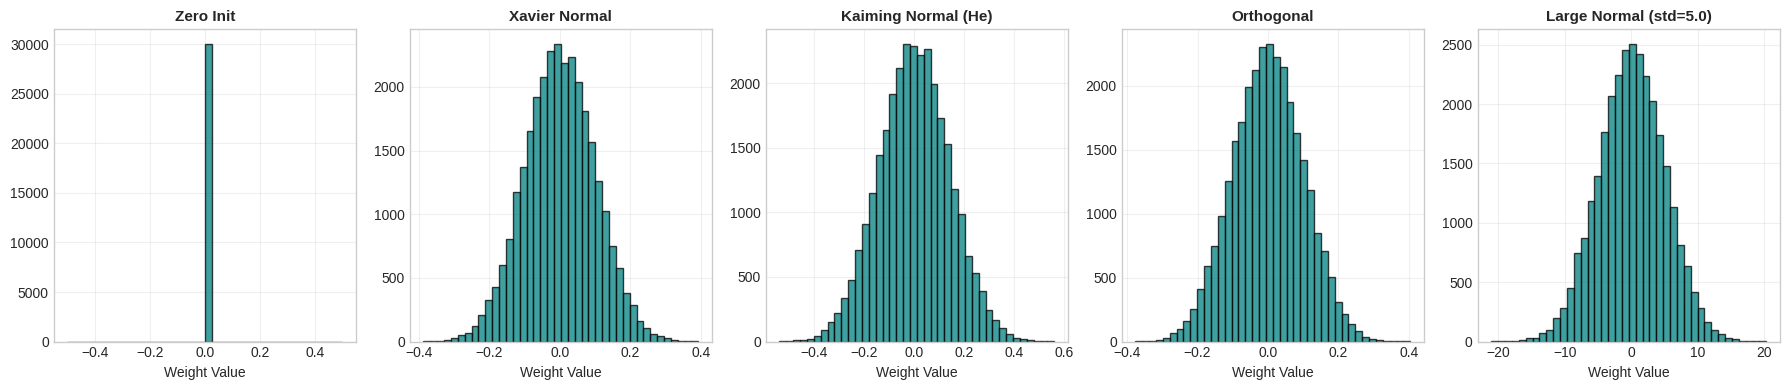

In [3]:
def get_weight_distributions(init_fn):
    model = nn.Sequential(
        nn.Linear(100, 100),
        nn.Linear(100, 100),
        nn.Linear(100, 100)
    )
    model.apply(init_fn)
    
    weights = []
    for name, p in model.named_parameters():
        if 'weight' in name:
            weights.append(p.detach().numpy().flatten())
    return weights

inits = {
    'Zero Init': init_weights_zero,
    'Xavier Normal': init_weights_xavier_normal,
    'Kaiming Normal (He)': init_weights_kaiming_normal,
    'Orthogonal': init_weights_orthogonal,
    'Large Normal (std=5.0)': init_weights_exploding
}

fig, axes = plt.subplots(1, len(inits), figsize=(18, 4))

for i, (name, fn) in enumerate(inits.items()):
    w_list = get_weight_distributions(fn)
    all_w = np.concatenate(w_list)
    axes[i].hist(all_w, bins=40, color='teal', alpha=0.75, edgecolor='black')
    axes[i].set_title(name, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Weight Value')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 3. Investigating Gradient Dynamics in Deep Networks (10 Layers)

To directly observe gradient flow, we construct a 10-layer deep neural network and use **PyTorch Backward Hooks** (`register_full_backward_hook`) to intercept and record gradient norms per layer.


In [4]:
class Deep10LayerANN(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        layers = []
        layers.append(nn.Linear(64, hidden_dim))
        layers.append(nn.ReLU())
        for _ in range(8):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.ReLU())
        layers.append(nn.Linear(hidden_dim, 10))
        self.net = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.net(x)

def measure_gradient_flow(init_fn):
    model = Deep10LayerANN()
    model.apply(init_fn)
    
    grad_norms = []
    
    # Hook function to record gradient norm of each linear layer
    def hook_fn(module, grad_input, grad_output):
        if grad_output[0] is not None:
            norm = grad_output[0].norm().item()
            grad_norms.append(norm)
            
    # Register hooks on all Linear modules
    hooks = []
    for m in model.modules():
        if isinstance(m, nn.Linear):
            h = m.register_full_backward_hook(hook_fn)
            hooks.append(h)
            
    # Forward and backward pass with dummy batch
    dummy_input = torch.randn(32, 64)
    dummy_target = torch.randint(0, 10, (32,))
    criterion = nn.CrossEntropyLoss()
    
    out = model(dummy_input)
    loss = criterion(out, dummy_target)
    loss.backward()
    
    # Remove hooks
    for h in hooks:
        h.remove()
        
    # Reverse grad_norms so index 0 corresponds to Layer 1 (Input layer)
    return grad_norms[::-1]

gradient_experiments = {
    'Zero Init (Gradients = 0)': init_weights_zero,
    'Xavier Normal': init_weights_xavier_normal,
    'Kaiming Normal (Healthy)': init_weights_kaiming_normal,
    'Exploding (std=5.0)': init_weights_exploding
}

results = {}
for name, fn in gradient_experiments.items():
    results[name] = measure_gradient_flow(fn)


/tmp/ipykernel_5345/850971149.py:42: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


## 4. Visualizing Vanishing vs Exploding Gradients

- **Zero Init**: Gradients vanish completely to zero or fail to break symmetry.
- **Exploding Init**: Gradients grow exponentially to extreme values ($>10^5$).
- **Kaiming Normal**: Gradients remain stable ($\sim 1.0$) across all 10 layers.


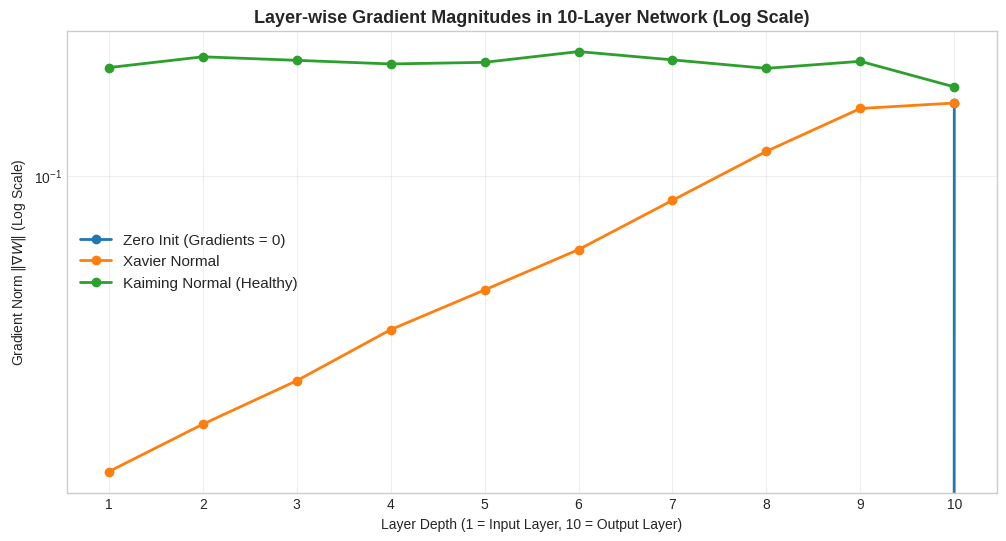

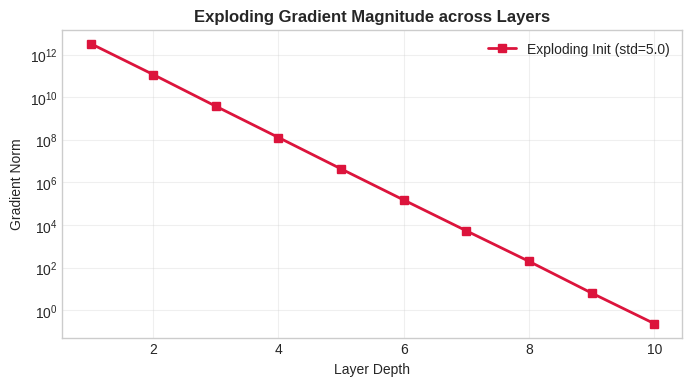

In [6]:
plt.figure(figsize=(12, 6))

for name, norms in results.items():
    if 'Exploding' in name:
        # Plot on secondary log scale visually
        continue
    layers = list(range(1, len(norms) + 1))
    plt.plot(layers, norms, marker='o', linewidth=2, label=name)

plt.yscale('log')
plt.title('Layer-wise Gradient Magnitudes in 10-Layer Network (Log Scale)', fontsize=13, fontweight='bold')
plt.xlabel('Layer Depth (1 = Input Layer, 10 = Output Layer)')
plt.ylabel(r'Gradient Norm $\|\nabla W\|$ (Log Scale)')
plt.xticks(range(1, 11))
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

# Separate plot for Exploding Gradients
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(results['Exploding (std=5.0)']) + 1), results['Exploding (std=5.0)'],
         marker='s', color='crimson', linewidth=2, label='Exploding Init (std=5.0)')
plt.yscale('log')
plt.title('Exploding Gradient Magnitude across Layers', fontsize=12, fontweight='bold')
plt.xlabel('Layer Depth')
plt.ylabel('Gradient Norm')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 5. Summary & Best Practices Matrix

| Activation Function      | Recommended Weight Initialization (`torch.nn.init`) | PyTorch Function                               |
| :----------------------- | :-------------------------------------------------- | :--------------------------------------------- |
| **ReLU / LeakyReLU**     | Kaiming / He (Normal or Uniform)                    | `init.kaiming_normal_(w, nonlinearity='relu')` |
| **Sigmoid / Tanh**       | Xavier / Glorot (Normal or Uniform)                 | `init.xavier_normal_(w)`                       |
| **Linear / Softmax**     | Xavier Uniform / Small Normal                       | `init.xavier_uniform_(w)`                      |
| **RNNs / Deep Residual** | Orthogonal                                          | `init.orthogonal_(w)`                          |
